**Car Price Prediction**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv('/content/Car_data_jtrjuw.csv')

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Business Problem

An online car marketplace wants to estimate the selling price of used cars based on vehicle characteristics such as year, mileage, fuel type, transmission type, and current market value.

Build a machine learning model that predicts the selling price of a car.

**Objective**

Build a machine learning model that predicts the selling price of a car.

**Target Variable**

Selling_Price

**Features**
Car_Name
Year
Present_Price
Kms_Driven
Fuel_Type
Seller_Type
Transmission
Owner

In [4]:
df.shape

(301, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [7]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

#Checking Missing Values

In [9]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


**Observation**

The dataset contains no missing values.

# Checking For Dupilcate

In [10]:
df.duplicated().sum()

np.int64(2)

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(299, 9)

In [14]:
df.to_csv('/content/Car_data_jtrjuw.csv', index=False)

# Price Distribution

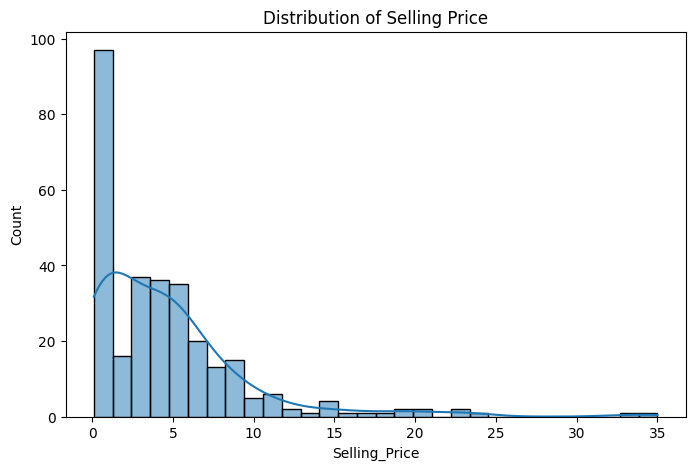

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Selling_Price'], bins=30, kde=True)
plt.title('Distribution of Selling Price')
plt.show()

Most cars are sold at lower prices, while only a few cars have very high selling prices. This indicates a right-skewed distribution.

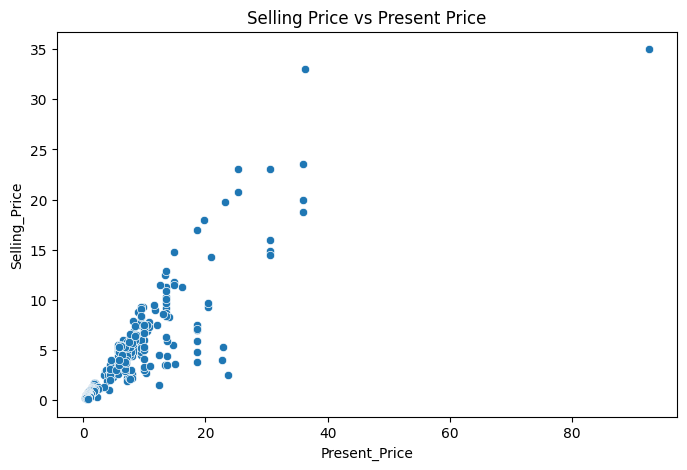

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Present_Price',
    y='Selling_Price',
    data=df
)

plt.title('Selling Price vs Present Price')
plt.show()

There is a strong positive relationship between present price and selling price. Cars with higher showroom prices tend to have higher resale values.

# Selling Price vs Year

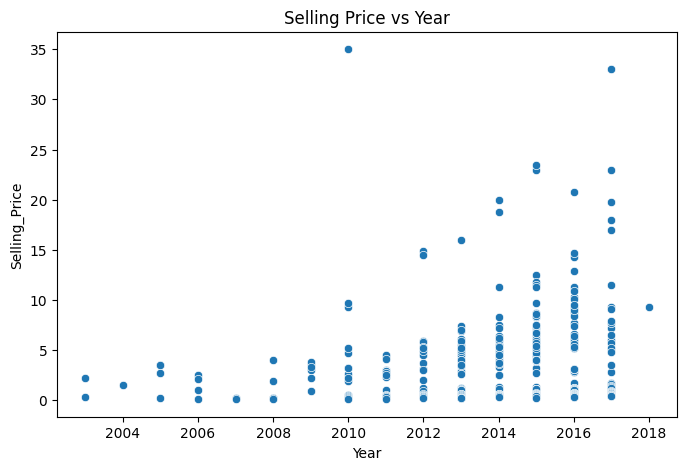

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Year',
    y='Selling_Price',
    data=df
)

plt.title('Selling Price vs Year')
plt.show()

Newer vehicles generally have higher selling prices compared to older vehicles.

# Selling Price vs Kilometers Driven

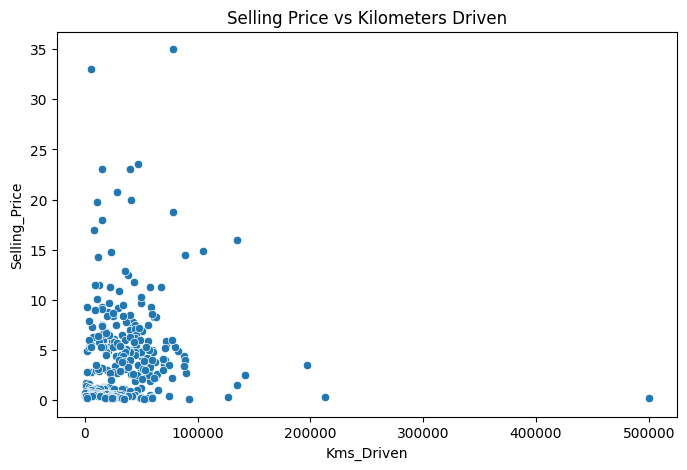

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Kms_Driven',
    y='Selling_Price',
    data=df
)

plt.title('Selling Price vs Kilometers Driven')
plt.show()

Cars with higher mileage generally sell for lower prices.

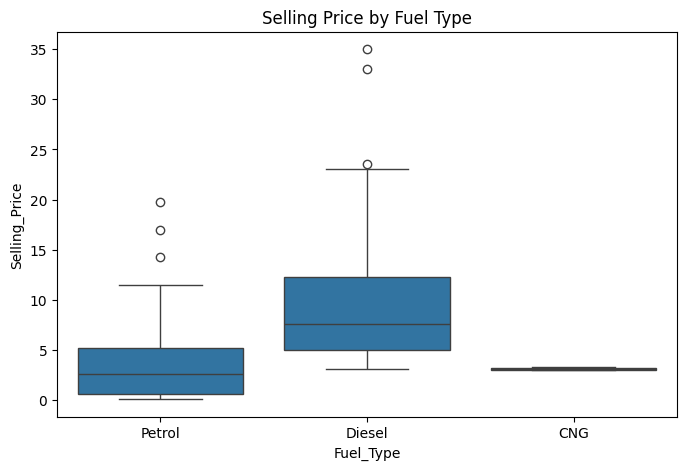

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Fuel_Type',
    y='Selling_Price',
    data=df
)

plt.title('Selling Price by Fuel Type')
plt.show()

Diesel cars generally have higher selling prices than petrol and CNG vehicles.

# Correlation Heatmap

In [20]:
eda_df = df.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Car_Name','Fuel_Type','Seller_Type','Transmission']:
    eda_df[col] = le.fit_transform(eda_df[col])

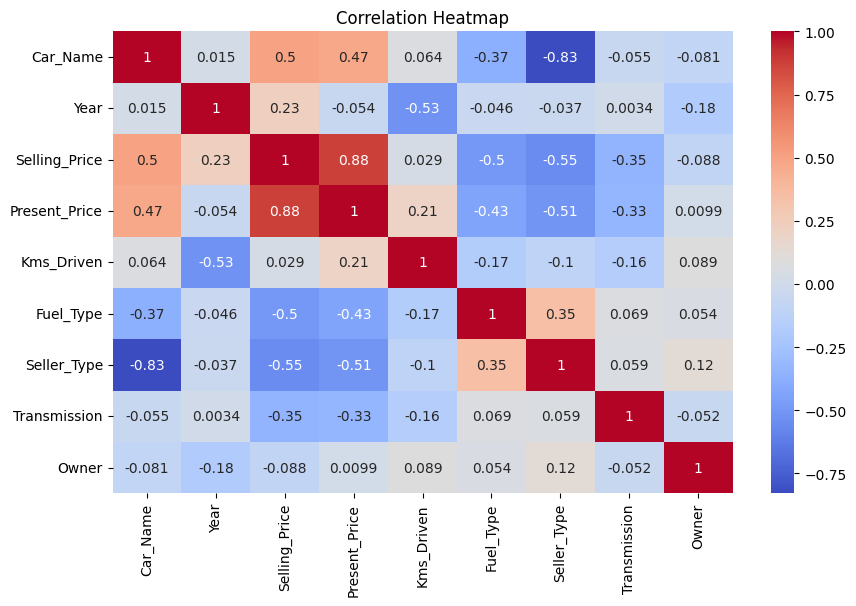

In [21]:
plt.figure(figsize=(10,6))

sns.heatmap(
    eda_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

Present Price shows the strongest positive correlation with Selling Price, while vehicle age and kilometers driven negatively affect resale value.

# Data Preprocessing

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['Car_Name','Fuel_Type','Seller_Type','Transmission']:
    df[col] = le.fit_transform(df[col])

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,90,2014,3.35,5.59,27000,2,0,1,0
1,93,2013,4.75,9.54,43000,1,0,1,0
2,68,2017,7.25,9.85,6900,2,0,1,0
3,96,2011,2.85,4.15,5200,2,0,1,0
4,92,2014,4.60,6.87,42450,1,0,1,0


# Define Features and Target

In [23]:
X = df.drop('Selling_Price', axis=1)

y = df['Selling_Price']


# Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the Linear Regression Model

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

# Make Predictions

In [27]:
y_pred = model.predict(X_test)

y_pred[:10]

array([ 7.50312945,  7.5393869 ,  1.31974879,  6.76386908, 11.2251942 ,
        4.49174464,  8.54823629,  1.78979001,  8.71953242, -1.00564316])

# Evaluate the Model
Mean Absolute Error (MAE)

In [28]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 1.571163685627316


MAE shows the average error between the actual and predicted car prices.
Lower values indicate better performance.

# Root Mean Squared Error

In [29]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 2.612148333018212


RMSE penalizes large prediction errors more heavily than MAE.
A lower RMSE indicates better model performance.

# R² Score

In [30]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.7352559076589605


R² measures how much variation in Selling Price is explained by the model.
Values closer to 1 indicate a stronger model.

# Compare Actual vs Predicted Prices

In [31]:
results = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

results.head(10)

,Actual Price,Predicted Price
283,8.99,7.503129
267,8.35,7.539387
166,0.45,1.319749
9,7.45,6.763869
78,5.25,11.225194
280,5.25,4.491745
95,5.85,8.548236
111,1.15,1.789790
5,9.25,8.719532
175,0.38,-1.005643


# Visualization of Predictions

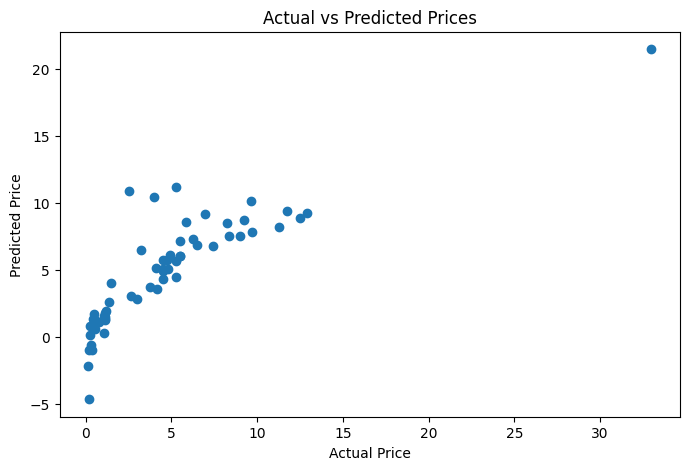

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

The closer the points are to an imaginary diagonal line, the more accurate the predictions.

# Predict Prices for 5 Sample Cars

In [33]:
sample_cars = X_test[:5]

sample_predictions = model.predict(sample_cars)

sample_predictions

array([ 7.50312945,  7.5393869 ,  1.31974879,  6.76386908, 11.2251942 ])

In [34]:
prediction_df = pd.DataFrame({
    "Predicted Price": sample_predictions
})

prediction_df

,Predicted Price
0,7.503129
1,7.539387
2,1.319749
3,6.763869
4,11.225194


# Determine the Most Important Factors

In [35]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
2,Present_Price,3.885201
1,Year,0.990146
0,Car_Name,0.139274
7,Owner,0.129436
3,Kms_Driven,-0.262848
4,Fuel_Type,-0.485790
5,Seller_Type,-0.508499
6,Transmission,-0.531312


In [36]:
importance.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

,Feature,Coefficient
2,Present_Price,3.885201
1,Year,0.990146
6,Transmission,-0.531312
5,Seller_Type,-0.508499
4,Fuel_Type,-0.485790
3,Kms_Driven,-0.262848
0,Car_Name,0.139274
7,Owner,0.129436


# Insights and Findings.




Present_Price has the strongest impact on Selling_Price.
Newer cars generally sell for higher prices.
Cars with lower mileage tend to retain more value.
Automatic vehicles often command higher prices.

# Surprising Findings

Some older cars still have relatively high selling prices because of their high showroom value.
Owner count has less impact than expected.
Present_Price alone explains a large portion of the variation in selling price.

# Conclusion

This project developed a Linear Regression model to predict the selling price of used cars based on their features. The dataset was explored, cleaned, and preprocessed before training the model. The model was evaluated using MAE, RMSE, and R² Score.

The results indicate that the model is capable of predicting car prices with reasonable accuracy. Features such as Present Price, Year, and Kilometers Driven were found to have the greatest influence on a car's selling price.

This model can help an online car marketplace estimate fair selling prices and support better decision-making for buyers and sellers.